# IMEN266 · Ch.8 · Class Problems 11 — Markovian queues: $M/M/1$, $M/M/2$, $M/M/s$, $M/M/\infty$, Little's law, PASTA

**How this notebook works** — every problem follows the same 5 steps:

> **Problem → Model → Analytic → Simulate & Visualize → Experiment**

The analytic answer and the simulation must agree. *That agreement — not the
instructor, not an AI — is your ground truth.*

**In-class version only:** cells marked `# TODO` are for you to complete during
class. A `check(...)` cell right after tells you immediately whether your answer
matches the reference value.

▶ Open in Colab: `https://colab.research.google.com/github/youngmko/imen266-2026/blob/main/ch08/notebooks/CP11_markovian_queues.ipynb`

**The facts of this notebook** *(slides pp. 5–22/66; Companion Proofs 1–4)*

- **Birth–death queues:** the cut equations $\lambda_n p_n=\mu_{n+1}p_{n+1}$ give
  $p_n=p_0\prod_{k<n}\lambda_k/\mu_{k+1}$; the sum must converge (**stability**).
  $M/M/1$: $p_n=(1-\rho)\rho^n$, $L=\rho/(1-\rho)$, sojourn $\sim\exp(\mu-\lambda)$.
  $M/M/s$: two regimes, Erlang C $P(\text{wait})=p_s/(1-\rho)$. $M/M/\infty$: Poisson$(\lambda/\mu)$.
- **Little's law** $L=\lambda W$, $L_q=\lambda W_q$ (a time average $=$ rate $\times$ a customer
  average), plus $L=L_q+\lambda/\mu$ and $W=W_q+1/\mu$.
- **PASTA:** Poisson arrivals see the time-average state — the distribution seen by
  an arrival equals $(p_n)$. Not true for other arrival processes.

In code (course package `imen266.queueing`): `mm1`, `mms`, `mminf`, `erlang_c`,
`mm1_sojourn_tail`, `mm1_required_rate`, `pooling_compare`, `birth_death_stationary`,
the simulator `simulate_queue(arrival, service, T, rng, s=..., K=..., ...)` /
`SimQueue`, `little_check`, `pasta_demo`; from `imen266.ctmc`: `birth_death`, `bd_stationary`.

In [1]:
# --- IMEN266 setup (Ch.8): course package + helpers ---------------------------
import math
import numpy as np
import matplotlib.pyplot as plt
from scipy import stats

try:                                   # local clone / PLMS zip: package is on the path
    from imen266.queueing import mm1
except ImportError:                    # Colab: fetch the course package from GitHub (~5 s)
    import subprocess, sys
    subprocess.run([sys.executable, "-m", "pip", "install", "-q",
                    "git+https://github.com/youngmko/imen266-2026.git"], check=True)
    from imen266.queueing import mm1
from imen266.queueing import (mms, mminf, mm1k, mmsk, mmkk, erlang_b, erlang_c,
                              birth_death_stationary, truncate, mm1_sojourn_tail, mm1_required_rate,
                              mg1_pk, bulk_mm1, gg1_approx, ggm_approx, reneging_balking_rates,
                              jackson_solve, optimal_split, pooling_compare, braess,
                              SimQueue, simulate_queue, sim_network, little_check, pasta_demo)
from imen266.ctmc import CTMC, birth_death, bd_stationary, poisson_process
from imen266.check import check        # [TODO]/[OK]/[X] self-check (unfinished TODOs never crash)

rng = np.random.default_rng(2026)
plt.rcParams.update({"figure.figsize": (7, 4), "axes.grid": True,
                     "grid.alpha": .3, "axes.spines.top": False,
                     "axes.spines.right": False, "font.size": 11,
                     "legend.frameon": False})

def plot_queue_path(res, T_show=None, ax=None, title=None):
    """Step plot of the number in the system N(t) from a SimQueue / simulate_queue result."""
    ax = ax or plt.gca()
    t, n = res["t"], res["n"]
    if T_show is not None:
        m = t <= T_show
        t, n = np.append(t[m], T_show), np.append(n[m], n[m][-1])
    ax.step(t, n, where="post", lw=1)
    ax.set_xlabel("t"); ax.set_ylabel("number in system N(t)")
    if title: ax.set_title(title)
    return ax

def bd_diagram(births, deaths, states=None, ax=None):
    """Rate diagram of a finite birth-death chain (reuses CTMC.plot_rate_diagram, line layout)."""
    chain = birth_death(births, deaths, states=states)
    return chain.plot_rate_diagram(ax=ax, layout="line")

def ci95(x):
    """Half-width of a 95% confidence interval for the mean of the replications x."""
    x = np.asarray(x, dtype=float)
    return 1.96 * x.std(ddof=1) / math.sqrt(len(x)) if len(x) > 1 else np.nan

try:
    from ipywidgets import interact, FloatSlider, IntSlider, FloatLogSlider
    HAS_W = True
except Exception:
    HAS_W = False

def show(fn, **sliders):
    """interact() if widgets are available; otherwise draw once with defaults."""
    if HAS_W:
        interact(fn, **sliders)
    else:
        fn(**{k: getattr(v, "value", v) for k, v in sliders.items()})

print("Setup OK.  imen266.queueing imported.  Widgets available:", HAS_W)

Setup OK.  imen266.queueing imported.  Widgets available: True


---
## Warm-up · Little's law on one sample path *(slides pp. 5–6/66)*

Simulate an $M/M/1$ queue ($\lambda=0.8$, $\mu=1$) for a long time and measure three
things *without any formula*: the time average $L$ of the number in the system, the
rate $\lambda_{\text{eff}}$ at which customers get served, and the mean sojourn time $W$
over all served customers. Little's law says the three must satisfy $L=\lambda_{\text{eff}}W$.

time-average L = 3.722   served per unit time = 0.803   mean sojourn W = 4.634   mean wait Wq = 3.639


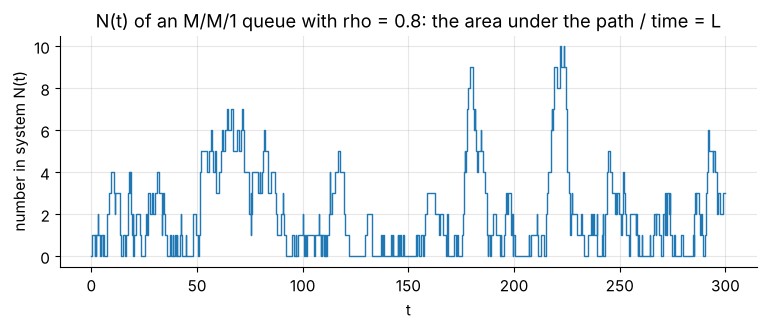

In [3]:
res = simulate_queue(0.8, 1.0, T=20_000, rng=rng, warmup=500)      # PP(0.8) arrivals, exp(1) service, 1 server
print(f"time-average L = {res['L']:.3f}   served per unit time = {res['lam_eff']:.3f}   mean sojourn W = {res['W']:.3f}   mean wait Wq = {res['Wq']:.3f}")
fig, ax = plt.subplots(figsize=(9, 3)); plot_queue_path(res, T_show=300, ax=ax, title="N(t) of an M/M/1 queue with rho = 0.8: the area under the path / time = L"); plt.show()

In [4]:
W_little = res["L"] / res["lam_eff"]                       # Little: W = L / lam
print(f"W from Little = {W_little:.3f}   measured W = {res['W']:.3f}   (Lq / lam = {res['Lq']/res['lam_eff']:.3f} vs measured Wq = {res['Wq']:.3f})")

W from Little = 4.634   measured W = 4.634   (Lq / lam = 3.639 vs measured Wq = 3.639)


In [5]:
check("Little: L / lam_eff equals the measured W", W_little, res["W"], rel=0.02)

[OK ] Little: L / lam_eff equals the measured W: got 4.63419   (reference 4.63419)


True

**Think about it** — (i) Little's law used nothing about Poisson arrivals or exponential
service; why? (Companion Proof 3: it is a renewal reward identity from Ch. 7.) (ii) The
servers alone form a "system" too: what does $L=\lambda W$ say about them?

---
## Problem 1 — $M/M/1$: stationary distribution, $L$, $W$, and the blow-up near $\rho=1$ *(slides pp. 7–11/66)*

> Customers arrive according to $PP(\lambda)$ to a single server with $\exp(\mu)$ service
> times and unlimited waiting room. Find the stationary distribution of the number in
> the system and the four performance measures; what happens as $\lambda\uparrow\mu$?

### Model
Birth–death CTMC with $\lambda_n=\lambda$, $\mu_n=\mu$: cut equations $\lambda p_n=\mu p_{n+1}$,
$p_n=(1-\rho)\rho^n$ for $\rho=\lambda/\mu<1$; $L=\rho/(1-\rho)$, $W=L/\lambda$, $W_q=W-1/\mu$,
$L_q=\lambda W_q$. Numbers: a help desk with $\lambda=4$ calls/h and $1/\mu=12$ min ($\mu=5$/h).

In [6]:
lam, mu = 4.0, 5.0                                           # per hour
rho = lam / mu
p0 = 1 - rho
L  = rho / (1 - rho)
W  = L / lam                                                 # hours
Wq = W - 1 / mu
Lq = lam * Wq
print(f"rho = {rho}   p0 = {p0:.3f}   L = {L:.3f}   W = {W:.3f} h   Wq = {Wq:.3f} h   Lq = {Lq:.3f}")

rho = 0.8   p0 = 0.200   L = 4.000   W = 1.000 h   Wq = 0.800 h   Lq = 3.200


In [7]:
check("rho = lam/mu",          rho, 0.8,  tol=1e-9)
check("p0 = 1 - rho",          p0,  0.2,  tol=1e-9)
check("L = rho/(1-rho)",       L,   4.0,  tol=1e-9)
check("W = 1/(mu - lam) hours", W,   1.0,  tol=1e-9)
check("Wq = W - 1/mu",         Wq,  0.8,  tol=1e-9)
check("Lq = lam Wq",           Lq,  3.2,  tol=1e-9)

[OK ] rho = lam/mu: got 0.8   (reference 0.8)
[OK ] p0 = 1 - rho: got 0.2   (reference 0.2)
[OK ] L = rho/(1-rho): got 4   (reference 4)
[OK ] W = 1/(mu - lam) hours: got 1   (reference 1)
[OK ] Wq = W - 1/mu: got 0.8   (reference 0.8)
[OK ] Lq = lam Wq: got 3.2   (reference 3.2)


True

simulation: L = 4.055  Lq = 3.252  W = 1.010  Wq = 0.810    theory: L = 4.000  Lq = 3.200  W = 1.000  Wq = 0.800


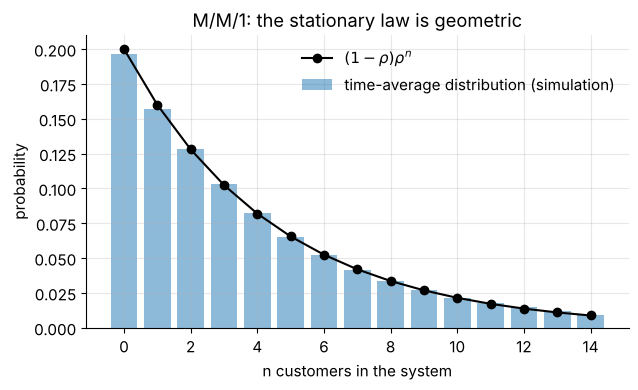

In [8]:
# --- Simulate the help desk and compare the time-average distribution with (1-rho) rho^n -----------------
ref = mm1(4.0, 5.0)                                                       # independent of your TODO
res = simulate_queue(4.0, 5.0, T=50_000, rng=rng, warmup=1_000)          # 50,000 hours
print(f"simulation: L = {res['L']:.3f}  Lq = {res['Lq']:.3f}  W = {res['W']:.3f}  Wq = {res['Wq']:.3f}    theory: L = {ref['L']:.3f}  Lq = {ref['Lq']:.3f}  W = {ref['W']:.3f}  Wq = {ref['Wq']:.3f}")
n = np.arange(15)
plt.figure(figsize=(7, 3.8))
plt.bar(n, res["p_time"][:15], alpha=.5, label="time-average distribution (simulation)")
plt.plot(n, ref["pn"](n), "ko-", label="$(1-\\rho)\\rho^n$")
plt.xlabel("n customers in the system"); plt.ylabel("probability"); plt.legend()
plt.title("M/M/1: the stationary law is geometric"); plt.show()

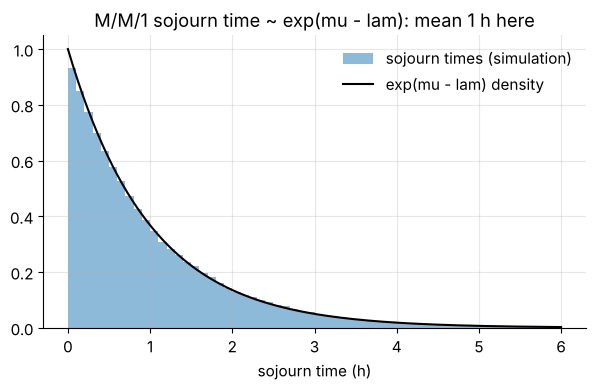

P(sojourn > 2 h): simulation 0.1396   theory e^{-2} = 0.1353


In [9]:
# --- The sojourn-time distribution is exp(mu - lam), not just its mean ----------------------------------------
x = np.linspace(0, 6, 200)
plt.figure(figsize=(7, 3.8))
plt.hist(res["sojourns"], bins=60, range=(0, 6), density=True, alpha=.5, label="sojourn times (simulation)")
plt.plot(x, (5 - 4) * np.exp(-(5 - 4) * x), "k", label="exp(mu - lam) density")
plt.xlabel("sojourn time (h)"); plt.legend(); plt.title("M/M/1 sojourn time ~ exp(mu - lam): mean 1 h here"); plt.show()
print("P(sojourn > 2 h): simulation", np.mean(res["sojourns"] > 2).round(4), "  theory e^{-2} =", round(math.exp(-2), 4))

### Final-style · choosing the service rate *(2024 final Q2)*
The help desk must guarantee $P(\text{sojourn}>x)\le\varepsilon$ with $x=30$ min and
$\varepsilon=0.05$. Since the sojourn time is $\exp(\mu-\lambda)$, $e^{-(\mu-\lambda)x}\le\varepsilon$
gives the smallest (cheapest) rate $\mu^*=\lambda+\ln(1/\varepsilon)/x$.

In [10]:
x_lim, eps = 0.5, 0.05                                        # 30 minutes, 5 %
mu_star = lam + math.log(1 / eps) / x_lim
print(f"mu* = {mu_star:.3f} per hour (mean service {60/mu_star:.2f} min);  check: P(W > x) = {math.exp(-(mu_star - lam) * x_lim):.4f}")

mu* = 9.991 per hour (mean service 6.01 min);  check: P(W > x) = 0.0500


In [11]:
check("mu* = lam + ln(1/eps)/x", mu_star, 4 + math.log(20) / 0.5, tol=1e-6)

[OK ] mu* = lam + ln(1/eps)/x: got 9.99146   (reference 9.99146)


True

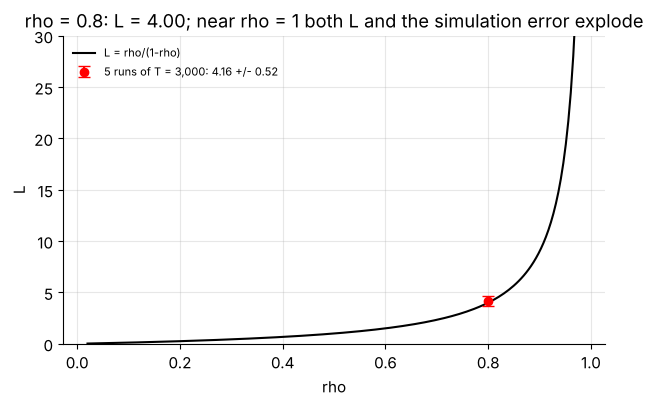

In [12]:
def mm1_demo(rho=0.8):
    """L against rho, with a simulated point: the hyperbola rho/(1-rho) and how noisy a fixed-length run gets."""
    rr = np.linspace(0.02, 0.98, 200)
    plt.figure(figsize=(7, 4)); plt.plot(rr, rr / (1 - rr), "k", label="L = rho/(1-rho)")
    sims = [simulate_queue(rho, 1.0, T=3_000, rng=rng, warmup=300)["L"] for _ in range(5)]
    plt.errorbar([rho], [np.mean(sims)], yerr=[ci95(sims)], fmt="ro", capsize=4, label=f"5 runs of T = 3,000: {np.mean(sims):.2f} +/- {ci95(sims):.2f}")
    plt.ylim(0, 30); plt.xlabel("rho"); plt.ylabel("L"); plt.legend(fontsize=8)
    plt.title(f"rho = {rho}: L = {rho/(1-rho):.2f}; near rho = 1 both L and the simulation error explode"); plt.show()

show(mm1_demo, rho=FloatSlider(min=0.1, max=0.98, step=0.02, value=0.8) if HAS_W else 0.8)

In [13]:
# --- How long must a run be? Relative error of the time-average L as rho -> 1 (10 replications of T = 5,000) ---
print(f"{'rho':>5} {'L theory':>9} {'mean of 10 runs':>16} {'95% half-width':>15} {'relative':>9}")
for rho_ in [0.5, 0.8, 0.9, 0.95]:
    Ls = np.array([simulate_queue(rho_, 1.0, T=5_000, rng=rng, warmup=500)["L"] for _ in range(10)])
    print(f"{rho_:>5} {rho_/(1-rho_):>9.2f} {Ls.mean():>16.2f} {ci95(Ls):>15.2f} {ci95(Ls)/Ls.mean():>9.1%}")
print("The run length needed for a given relative accuracy grows roughly like 1/(1-rho)^2 (HW5 Part C).")

  rho  L theory  mean of 10 runs  95% half-width  relative
  0.5      1.00             0.99            0.03      3.5%
  0.8      4.00             3.92            0.48     12.2%


  0.9      9.00            10.81            4.28     39.6%
 0.95     19.00            16.21            2.69     16.6%
The run length needed for a given relative accuracy grows roughly like 1/(1-rho)^2 (HW5 Part C).


**Think about it** — (i) $\rho=0.9$ gives $L=9$, $\rho=0.99$ gives $L=99$: a 10 % change in
load multiplies the queue by 11. Where is that nonlinearity in the derivation (slide
p. 10/66)? (ii) Why does the simulation get noisier as $\rho\to1$? (Hint: a busy period of
an $M/M/1$ has mean $1/(\mu-\lambda)$ but a variance that explodes much faster.)

---
## Problem 2 — Two servers of rate $\mu$ or one server of rate $2\mu$? *(slides pp. 12–15/66; homework08 Q5 of 2025)*

> System 1 has two servers, each serving at rate $\mu$; system 2 has a single server of
> rate $2\mu$. Both receive $PP(\lambda)$ arrivals, $\lambda<2\mu$. Which has the smaller $L$?
> Which has the smaller $L_q$?

### Model
System 1 is the $M/M/2$ queue: $p_0=\frac{2\mu-\lambda}{2\mu+\lambda}$,
$L=\frac{4\lambda\mu}{4\mu^2-\lambda^2}$ (slide p. 15/66). System 2 is $M/M/1$ with rate $2\mu$:
$L=\frac{\lambda}{2\mu-\lambda}$. In both, $L_q=L-\lambda/\mu_{\text{total}}$ with
$\mu_{\text{total}}=2\mu$ the total service capacity. Numbers: $\lambda=1.5$, $\mu=1$.

In [14]:
lam, mu = 1.5, 1.0
L_two  = 4 * lam * mu / (4 * mu**2 - lam**2)                 # M/M/2, each server rate mu
L_fast = lam / (2 * mu - lam)                                # M/M/1 with rate 2 mu
Lq_two  = L_two  - lam / mu                                  # mean number in service = lam/mu (two servers of rate mu)
Lq_fast = L_fast - lam / (2 * mu)                            # ... = lam/(2mu) for the fast single server
print(f"two servers: L = {L_two:.4f}, Lq = {Lq_two:.4f}     one fast server: L = {L_fast:.4f}, Lq = {Lq_fast:.4f}")

two servers: L = 3.4286, Lq = 1.9286     one fast server: L = 3.0000, Lq = 2.2500


In [15]:
check("M/M/2: L = 4 lam mu/(4mu^2 - lam^2)", L_two,   4*1.5/(4 - 2.25), tol=1e-9)
check("M/M/1(2mu): L = lam/(2mu - lam)",      L_fast,  1.5/0.5,           tol=1e-9)
check("M/M/2: Lq = L - lam/mu",               Lq_two,  4*1.5/(4 - 2.25) - 1.5, tol=1e-9)
check("M/M/1(2mu): Lq = L - lam/(2mu)",       Lq_fast, 3 - 0.75,          tol=1e-9)

[OK ] M/M/2: L = 4 lam mu/(4mu^2 - lam^2): got 3.42857   (reference 3.42857)
[OK ] M/M/1(2mu): L = lam/(2mu - lam): got 3   (reference 3)
[OK ] M/M/2: Lq = L - lam/mu: got 1.92857   (reference 1.92857)
[OK ] M/M/1(2mu): Lq = L - lam/(2mu): got 2.25   (reference 2.25)


True

In [16]:
# --- Simulate both systems ------------------------------------------------------------------------------
ref2, ref1 = mms(1.5, 1.0, 2), mm1(1.5, 2.0)                               # independent of your TODO
s2 = simulate_queue(1.5, 1.0, T=100_000, rng=rng, s=2, warmup=500)
s1 = simulate_queue(1.5, 2.0, T=100_000, rng=rng, s=1, warmup=500)
print(f"{'':>18} {'L sim':>7} {'L theory':>9} {'Lq sim':>7} {'Lq theory':>10} {'W sim':>7} {'Wq sim':>7}")
print(f"{'two servers (mu)':>18} {s2['L']:>7.3f} {ref2['L']:>9.3f} {s2['Lq']:>7.3f} {ref2['Lq']:>10.3f} {s2['W']:>7.3f} {s2['Wq']:>7.3f}")
print(f"{'one server (2mu)':>18} {s1['L']:>7.3f} {ref1['L']:>9.3f} {s1['Lq']:>7.3f} {ref1['Lq']:>10.3f} {s1['W']:>7.3f} {s1['Wq']:>7.3f}")
print("The fast single server wins on L (and W): service itself takes half as long; the pair wins on Lq (and Wq):")
print("with one customer present the pair still has a free server, the fast server never leaves capacity idle while busy.")

                     L sim  L theory  Lq sim  Lq theory   W sim  Wq sim
  two servers (mu)   3.537     3.429   2.027      1.929   2.353   1.349
  one server (2mu)   2.974     3.000   2.225      2.250   1.983   1.483
The fast single server wins on L (and W): service itself takes half as long; the pair wins on Lq (and Wq):
with one customer present the pair still has a free server, the fast server never leaves capacity idle while busy.


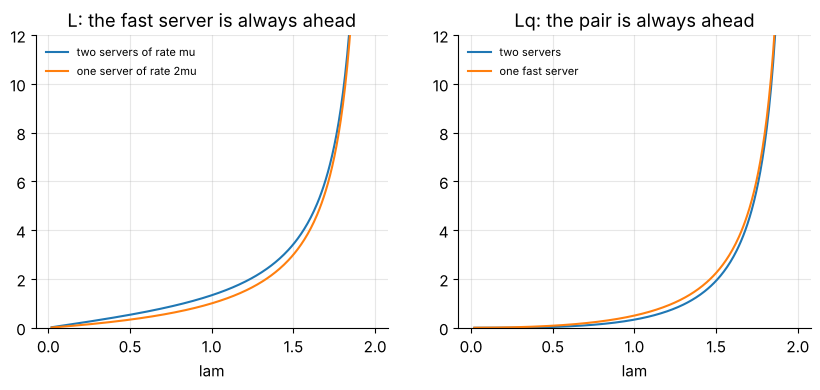

In [17]:
def two_vs_one(mu=1.0):
    """L and Lq of the two systems as functions of lam (0 < lam < 2 mu)."""
    ll = np.linspace(0.02, 2 * mu - 0.02, 300)
    L2 = 4 * ll * mu / (4 * mu**2 - ll**2); L1 = ll / (2 * mu - ll)
    fig, ax = plt.subplots(1, 2, figsize=(10, 3.8))
    ax[0].plot(ll, L2, label="two servers of rate mu"); ax[0].plot(ll, L1, label="one server of rate 2mu"); ax[0].set_title("L: the fast server is always ahead")
    ax[1].plot(ll, L2 - ll / mu, label="two servers"); ax[1].plot(ll, L1 - ll / (2 * mu), label="one fast server"); ax[1].set_title("Lq: the pair is always ahead")
    for a in ax: a.set_xlabel("lam"); a.set_ylim(0, 12); a.legend(fontsize=8)
    plt.show()

show(two_vs_one, mu=FloatSlider(min=0.5, max=3, step=0.1, value=1.0) if HAS_W else 1.0)

**Think about it** — (i) Show algebraically that $L_{\text{two}}>L_{\text{fast}}$ for every
$0<\lambda<2\mu$, and that $L_{q,\text{two}}<L_{q,\text{fast}}$. (ii) Which system would you choose for a
hospital emergency room, and which for a packet router? What is the criterion in each case?
(iii) Compare with CP13 §5 (pooling): one $M/M/2$ versus two separate $M/M/1$ queues.

---
## Problem 3 — $M/M/s$: how many tellers? *(slides pp. 16–19/66; homework08 Q4 of 2025)*

> A bank has 5 teller windows and a single line. Customers arrive according to
> $PP(\lambda)$ with $\lambda=40$ per hour; a transaction takes $\exp(\mu)$ with
> $1/\mu=6$ min. What fraction of customers has to wait, how long is the line on
> average, and how many windows are really needed?

### Model
$M/M/s$ with $a=\lambda/\mu=4$, $\rho=a/s$: $p_0=1/A$ with
$A=\sum_{i<s}\frac{a^i}{i!}+\frac{a^s}{s!}\frac{1}{1-\rho}$,
$P(\text{wait})=\frac{a^s}{s!}\frac{1}{1-\rho}p_0$ (**Erlang C**), $L_q=P(\text{wait})\frac{\rho}{1-\rho}$,
$L=L_q+a$, $W_q=L_q/\lambda$ (slides pp. 18–19/66).

In [18]:
lam, mu, s = 40.0, 10.0, 5                                   # per hour; a = 4, rho = 0.8
a, rho = lam / mu, lam / (s * mu)
A = sum(a**i / math.factorial(i) for i in range(s)) + a**s / math.factorial(s) / (1 - rho)
p0 = 1 / A
P_wait = a**s / math.factorial(s) / (1 - rho) * p0           # Erlang C
Lq = P_wait * rho / (1 - rho)
Wq_min = Lq / lam * 60                                       # minutes
print(f"p0 = {p0:.4f}   P(wait) = {P_wait:.4f}   Lq = {Lq:.3f}   Wq = {Wq_min:.2f} min   L = {Lq + a:.3f}")

p0 = 0.0130   P(wait) = 0.5541   Lq = 2.216   Wq = 3.32 min   L = 6.216


In [19]:
ref = mms(40.0, 10.0, 5)
check("p0 of M/M/5 with a = 4",   p0,     ref["p0"],        tol=1e-6)
check("Erlang C: P(wait)",         P_wait, erlang_c(4.0, 5), tol=1e-6)
check("Lq = P(wait) rho/(1-rho)",  Lq,     ref["Lq"],        tol=1e-6)
check("Wq in minutes",             Wq_min, ref["Wq"] * 60,   tol=1e-4)

[OK ] p0 of M/M/5 with a = 4: got 0.012987   (reference 0.012987)
[OK ] Erlang C: P(wait): got 0.554113   (reference 0.554113)
[OK ] Lq = P(wait) rho/(1-rho): got 2.21645   (reference 2.21645)
[OK ] Wq in minutes: got 3.32468   (reference 3.32468)


True

In [20]:
# --- Simulate the bank; the fraction of customers who wait is the fraction with a positive wait ------------------
res = simulate_queue(40.0, 10.0, T=20_000, rng=rng, s=5, warmup=200)     # 20,000 hours
ref = mms(40.0, 10.0, 5)
print(f"simulation: P(wait) = {np.mean(res['waits'] > 1e-12):.4f}  Lq = {res['Lq']:.3f}  Wq = {60*res['Wq']:.2f} min  L = {res['L']:.3f}   theory: {ref['Pwait']:.4f}, {ref['Lq']:.3f}, {60*ref['Wq']:.2f} min, {ref['L']:.3f}")
print(f"{'tellers s':>10} {'rho':>6} {'P(wait)':>8} {'Lq':>7} {'Wq (min)':>9}")
for s_ in range(5, 10):
    r = mms(40.0, 10.0, s_)
    print(f"{s_:>10} {r['rho']:>6.2f} {r['Pwait']:>8.3f} {r['Lq']:>7.3f} {60*r['Wq']:>9.2f}")

simulation: P(wait) = 0.5554  Lq = 2.269  Wq = 3.40 min  L = 6.269   theory: 0.5541, 2.216, 3.32 min, 6.216
 tellers s    rho  P(wait)      Lq  Wq (min)
         5   0.80    0.554   2.216      3.32
         6   0.67    0.285   0.570      0.85
         7   0.57    0.135   0.180      0.27
         8   0.50    0.059   0.059      0.09
         9   0.44    0.024   0.019      0.03


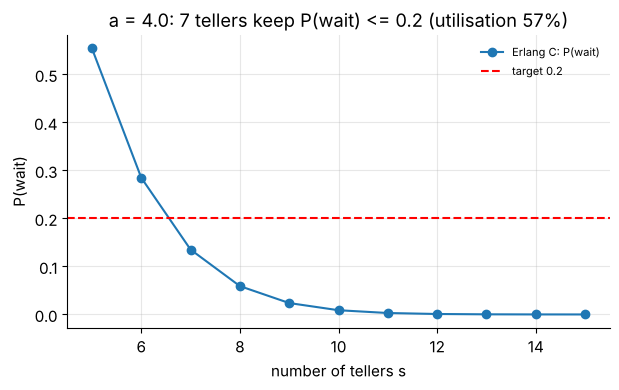

In [21]:
def tellers_demo(a=4.0, target=0.2):
    """Smallest number of tellers with P(wait) <= target for offered load a = lam/mu; the Erlang C curve."""
    ss = np.arange(int(np.ceil(a)) + (1 if a == int(a) else 0), int(a) + 12)
    C = np.array([erlang_c(a, s_) for s_ in ss])
    s_need = ss[np.argmax(C <= target)] if (C <= target).any() else None
    plt.figure(figsize=(7, 3.8)); plt.plot(ss, C, "o-", label="Erlang C: P(wait)")
    plt.axhline(target, color="r", ls="--", label=f"target {target}"); plt.xlabel("number of tellers s"); plt.ylabel("P(wait)"); plt.legend(fontsize=8)
    plt.title(f"a = {a}: {s_need} tellers keep P(wait) <= {target} (utilisation {a/s_need:.0%})" if s_need else f"a = {a}"); plt.show()

show(tellers_demo, a=FloatSlider(min=1, max=20, step=0.5, value=4.0) if HAS_W else 4.0,
     target=FloatSlider(min=0.05, max=0.5, step=0.05, value=0.2) if HAS_W else 0.2)

### The 2025 homework policy: windows that open as the line grows *(homework08 Q4)*
The bank opens one window for $0\le k\le5$ customers in the system, two for $6\le k\le8$,
three for $9\le k\le12$, four for $13\le k\le15$ and five for $k\ge16$. The number in the
system is still a birth–death chain — the death rate in state $k$ is
$\min(k,\text{open}(k))\,\mu$ — so `birth_death_stationary` solves it at once (truncate the
state space at a large $K$).

policy: L = 15.09, W = 22.6 min, mean windows open and busy = 4.00 (always-5 tellers: L = 6.22, W = 9.3 min, busy = 4)


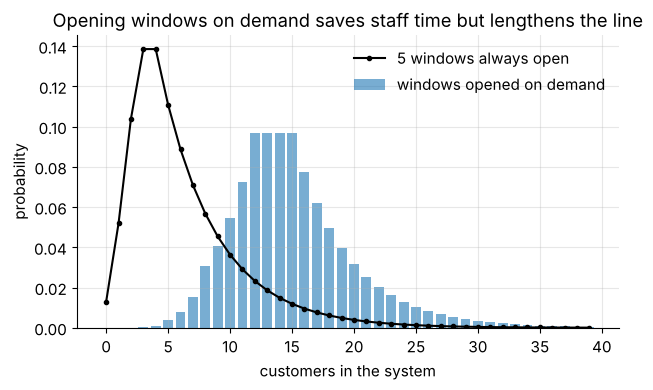

In [22]:
def windows_open(k):
    return 1 if k <= 5 else 2 if k <= 8 else 3 if k <= 12 else 4 if k <= 15 else 5

K = 200
births = np.full(K, 40.0)
deaths = np.array([min(k + 1, windows_open(k + 1)) * 10.0 for k in range(K)])    # rate out of state k+1
p_policy = birth_death_stationary(births, deaths)
n = np.arange(K + 1)
L_policy = (n * p_policy).sum()
busy_policy = sum(p_policy[k] * min(k, windows_open(k)) for k in n)
print(f"policy: L = {L_policy:.2f}, W = {60*L_policy/40:.1f} min, mean windows open and busy = {busy_policy:.2f} (always-5 tellers: L = {mms(40,10,5)['L']:.2f}, W = {60*mms(40,10,5)['W']:.1f} min, busy = 4)")
plt.figure(figsize=(7, 3.8)); plt.bar(n[:40], p_policy[:40], alpha=.6, label="windows opened on demand"); plt.plot(n[:40], mms(40, 10, 5)["pn"](n[:40]), "ko-", ms=3, label="5 windows always open")
plt.xlabel("customers in the system"); plt.ylabel("probability"); plt.legend(); plt.title("Opening windows on demand saves staff time but lengthens the line"); plt.show()

**Think about it** — (i) In the on-demand policy the long-run average number of busy
tellers is still exactly $a=4$ — why must that be so? (ii) What is the utilisation of an
*open* window under each policy? (iii) Why can the policy chain not be stable if the
largest number of windows times $\mu$ were below $\lambda$?

---
## Problem 4 — $M/M/\infty$: self-service *(slides pp. 20–22/66)*

> At the Drinks & Coffee station of the Bagels store (CP13 §2) customers serve
> themselves: arrivals $PP(\lambda)$ with $\lambda=0.741$ per minute, time at the station
> $\exp(\mu)$ with $1/\mu=2$ min. How many people are at the station on average, and
> how often is it empty?

### Model
Death rate $n\mu$ in state $n$ gives $p_n=e^{-\lambda/\mu}(\lambda/\mu)^n/n!$: the number present is
Poisson with mean $L=\lambda/\mu$, $W=1/\mu$, $L_q=W_q=0$ (slide p. 22/66).

In [23]:
lam, mu = 0.741, 0.5                                          # per minute
L = lam / mu
p_empty = math.exp(-lam / mu)
print(f"L = {L:.3f} customers,  P(empty) = {p_empty:.4f},  W = {1/mu:.1f} min")

L = 1.482 customers,  P(empty) = 0.2272,  W = 2.0 min


In [24]:
check("L = lam/mu",         L,       0.741 / 0.5,            tol=1e-9)
check("P(empty) = e^{-lam/mu}", p_empty, math.exp(-0.741 / 0.5), tol=1e-9)

[OK ] L = lam/mu: got 1.482   (reference 1.482)
[OK ] P(empty) = e^{-lam/mu}: got 0.227183   (reference 0.227183)


True

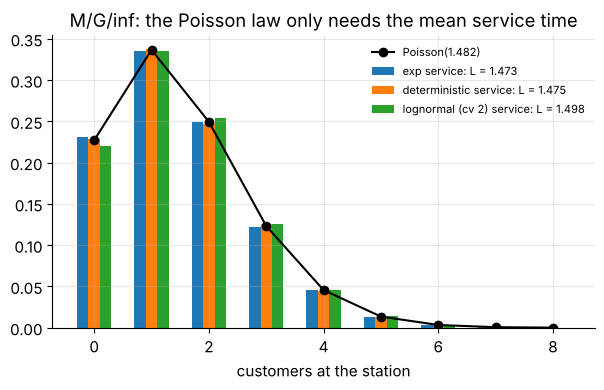

In [25]:
# --- Simulate with infinitely many servers; then change the service-time shape (M/G/inf is insensitive) --------
ref = mminf(0.741, 0.5)
res = simulate_queue(0.741, 0.5, T=30_000, rng=rng, s=np.inf, warmup=100)
det = simulate_queue(0.741, lambda r, n: np.full(n, 2.0), T=30_000, rng=rng, s=np.inf, warmup=100)        # deterministic 2 min
logn = simulate_queue(0.741, lambda r, n: r.lognormal(math.log(2) - 0.5*math.log(5), math.sqrt(math.log(5)), n), T=30_000, rng=rng, s=np.inf, warmup=100)  # lognormal, mean 2, cv 2
n = np.arange(9)
plt.figure(figsize=(7, 3.8))
plt.bar(n - 0.2, res["p_time"][:9], 0.2, label=f"exp service: L = {res['L']:.3f}")
plt.bar(n, det["p_time"][:9], 0.2, label=f"deterministic service: L = {det['L']:.3f}")
plt.bar(n + 0.2, logn["p_time"][:9], 0.2, label=f"lognormal (cv 2) service: L = {logn['L']:.3f}")
plt.plot(n, ref["pn"](n), "ko-", label=f"Poisson({ref['a']:.3f})")
plt.xlabel("customers at the station"); plt.legend(fontsize=8); plt.title("M/G/inf: the Poisson law only needs the mean service time"); plt.show()

**Think about it** — (i) Why is there no stability condition for $M/M/\infty$? (ii) The
same Poisson law appeared in Ch. 5 for the number of $PP(\lambda)$ arrivals still in service
at time $t$ ($M/G/\infty$); connect the two. (iii) In CP12 §3 the same chain is cut at $K$
servers — guess what the stationary law becomes.

---
## Section 5 — PASTA: Poisson Arrivals See Time Averages *(slides pp. 11, 24/66; Companion Proof 4)*

> The distribution of the number in the system *seen by an arriving customer* equals the
> time-average distribution $(p_n)$ — **if the arrivals are Poisson**. In an $M/M/1$ queue
> an arrival therefore finds the server busy with probability $\rho$ and sees $L$
> customers on average. With deterministic (or Erlang) arrivals of the same rate this fails.

In [26]:
lam, mu = 0.8, 1.0
P_busy_seen = lam / mu                                        # PASTA: = long-run fraction of time the server is busy
L_seen = (lam / mu) / (1 - lam / mu)                         # PASTA: = time-average L
print(f"M/M/1, rho = 0.8: an arrival finds the server busy w.p. {P_busy_seen:.2f} and sees {L_seen:.2f} customers on average")

M/M/1, rho = 0.8: an arrival finds the server busy w.p. 0.80 and sees 4.00 customers on average


In [27]:
check("PASTA: P(busy seen) = rho", P_busy_seen, 0.8, tol=1e-9)
check("PASTA: mean seen = L",        L_seen,      4.0, tol=1e-9)

[OK ] PASTA: P(busy seen) = rho: got 0.8   (reference 0.8)
[OK ] PASTA: mean seen = L: got 4   (reference 4)


True

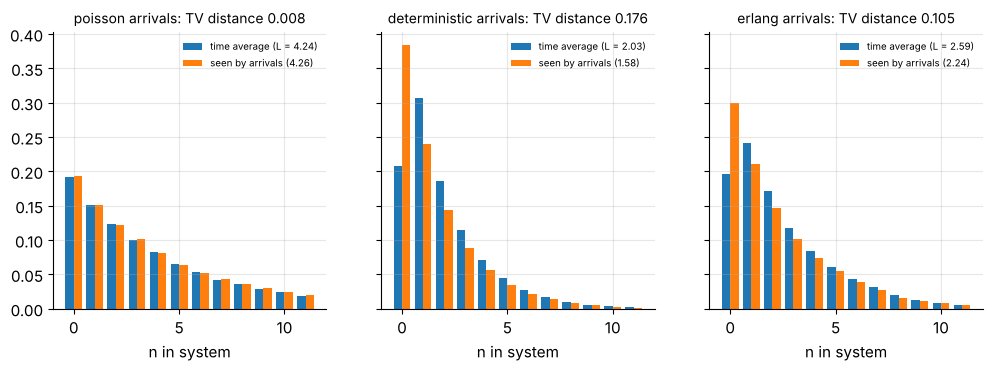

Only the Poisson arrivals see the time-average state; regular arrivals see fewer customers than there are on average.


In [28]:
# --- Arrival-average vs time-average for three arrival processes with the same rate ----------------------------
fig, ax = plt.subplots(1, 3, figsize=(12, 3.6), sharey=True)
for a, kind in zip(ax, ["poisson", "deterministic", "erlang"]):
    d = pasta_demo(0.8, 1.0, T=40_000, rng=rng, arrivals=kind)
    m = min(len(d["p_time"]), 12); n = np.arange(m)
    a.bar(n - 0.2, d["p_time"][:m], 0.4, label=f"time average (L = {d['L_time']:.2f})")
    a.bar(n + 0.2, d["p_arrival"][:m], 0.4, label=f"seen by arrivals ({d['L_arrival']:.2f})")
    a.set_title(f"{kind} arrivals: TV distance {d['tv_distance']:.3f}", fontsize=10); a.set_xlabel("n in system"); a.legend(fontsize=7)
plt.show()
print("Only the Poisson arrivals see the time-average state; regular arrivals see fewer customers than there are on average.")

**Think about it** — (i) Give an intuitive reason why *regular* (deterministic) arrivals
see a shorter queue than the time average. (ii) PASTA was used silently in the $M/G/1$
derivation of slide p. 35/66 and for the loss probability $p_K$ on slide p. 24/66 — find both
places. (iii) Is "departures see time averages" true in $M/M/1$? (Hint: slide p. 41/66, Burke.)

---
## Wrap-up

| question | tool | answer |
|---|---|---|
| warm-up | Little on a path | $L=\lambda_{\text{eff}}W$ holds for the raw simulation output |
| $M/M/1$ help desk (#1) | cut equations, geometric law | $\rho=0.8$, $L=4$, $W=1$ h, $W_q=0.8$ h, $L_q=3.2$; sojourn $\sim\exp(1)$; $\mu^*=10$/h for $P(W>30\text{ min})\le5\,\%$ |
| two servers vs one fast (#2) | $M/M/2$ vs $M/M/1(2\mu)$ | $\lambda=1.5,\mu=1$: $L$ 3.43 vs 3 (fast wins), $L_q$ 1.93 vs 2.25 (pair wins) |
| bank tellers (#3) | Erlang C | $a=4$, $s=5$: $P(\text{wait})=0.554$, $L_q=2.22$, $W_q=3.3$ min; on-demand windows lengthen the line |
| self-service (#4) | $M/M/\infty$ | Poisson$(1.482)$, $P(\text{empty})=0.227$, insensitive to the service law |
| PASTA (#5) | arrival vs time averages | equal for Poisson arrivals only |

**Next:** CP12 — finite capacity (loss, the effective arrival rate), Erlang loss,
truncation, $M/G/1$, bulk arrivals, reneging; then CP13 — networks of queues.